In [1]:
# ! pip install scikit-learn
# ! pip install seaborn

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

import seaborn as sns
import pandas as pd 

%config InlineBackend.figure_format='retina'
xr.set_options(display_style="text")


In [3]:
# Load mean sea surface temperature dataset
ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")

ds = xr.open_dataset("../../data/sst.wkmean.1990-present.nc", engine="netcdf4") # 1727 but no countries

# xarray's HTML representation
ds_copy = ds.copy(deep=True)

/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_6181/4275862908.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_6181/4275862908.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")


In [4]:
indices = np.argwhere(np.isnan(ds_ref.sst[0].data))
for (idx_y, idx_x) in indices:
    ds.sst[dict(lat=-idx_y, lon=idx_x)] = np.nan

In [5]:
# Region of interest: mediteranean sea

min_coords = [20.5, 0.5] #latitute, longitude
max_coords = [50.5, 40.5]

da = ds.sst

In [6]:
min_lat_idx = int(np.where(da.lat.data==max_coords[0])[0])
max_lat_idx = int(np.where(da.lat.data==min_coords[0])[0])

min_lon_idx = int(np.where(da.lon.data==min_coords[1])[0])
max_lon_idx = int(np.where(da.lon.data==max_coords[1])[0])

data_sq = da.data[:, min_lat_idx:max_lat_idx+1, min_lon_idx:max_lon_idx+1]

print("min/max lat/lon values", min_lat_idx, max_lat_idx, min_lon_idx, max_lon_idx)
print("data shape: ", data_sq.shape) # time, lat, lon
## time points frequency is ~ [1,2] weeks 

min/max lat/lon values 39 69 0 40
data shape:  (1727, 31, 41)


/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_6181/3594888808.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  min_lat_idx = int(np.where(da.lat.data==max_coords[0])[0])
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_6181/3594888808.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_lat_idx = int(np.where(da.lat.data==min_coords[0])[0])
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_6181/3594888808.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operatio

In [7]:
sst_med_sea = ds.sst[:,min_lat_idx:max_lat_idx+1, min_lon_idx:max_lon_idx+1]
sst_med_sea.shape, ds.sst.shape

((1727, 31, 41), (1727, 180, 360))

1. Compute Monthly Climatology

In [8]:
sst_gb = sst_med_sea.groupby("time.month", )

In [9]:
sst_gb

<DataArrayGroupBy, grouped over 1 grouper(s), 12 groups in total:
    'month': UniqueGrouper('month'), 12/12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12>

In [10]:
# tos clim contain the mean temperature per month across time.
tos_clim = sst_gb.mean(dim='time')
tos_std = sst_gb.std(dim='time') # interannual variability for each month
# tos_std = sst_gb.std(dim='time')**2

print(tos_clim.dims, tos_clim.shape)

('month', 'lat', 'lon') (12, 31, 41)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Mean/Std Climatology per month over period 1992 - 2023


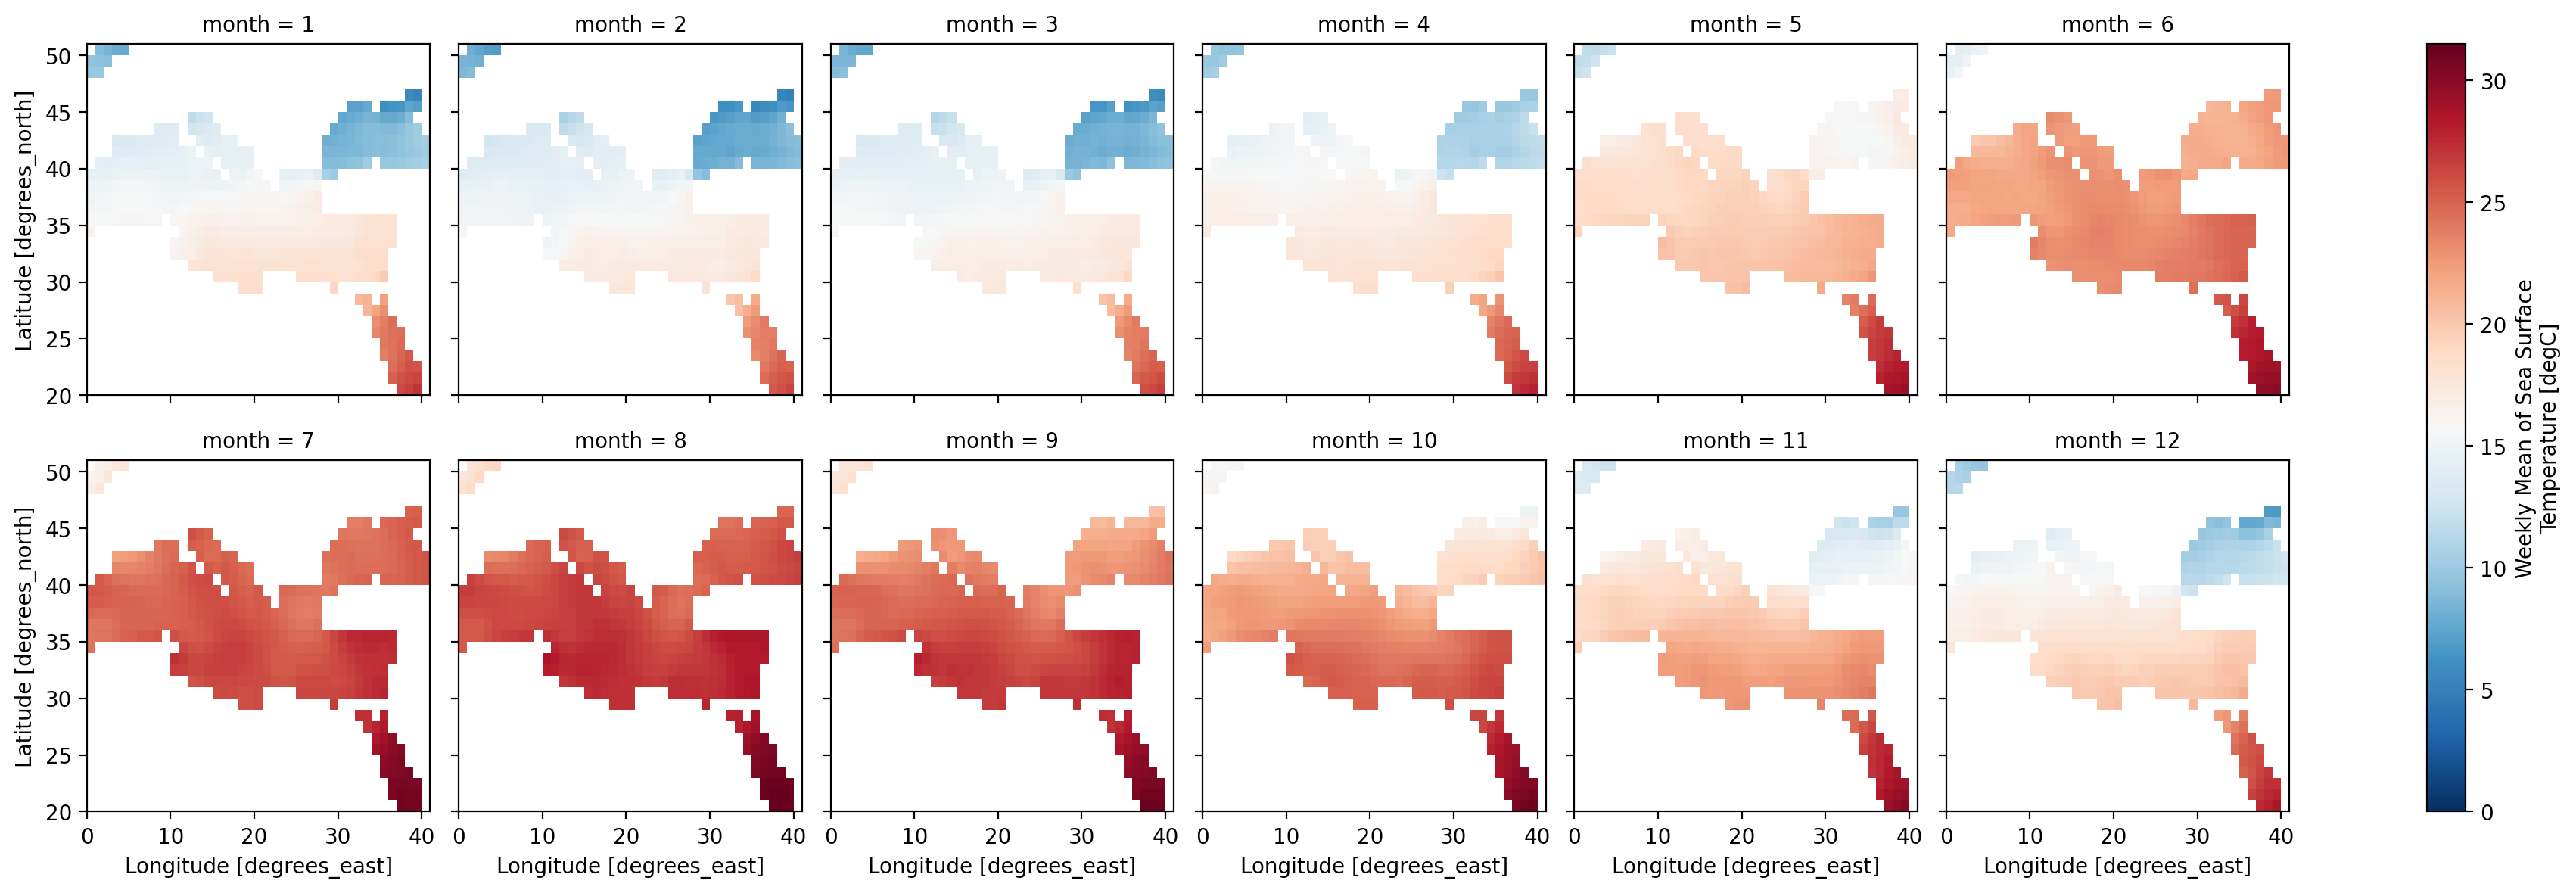

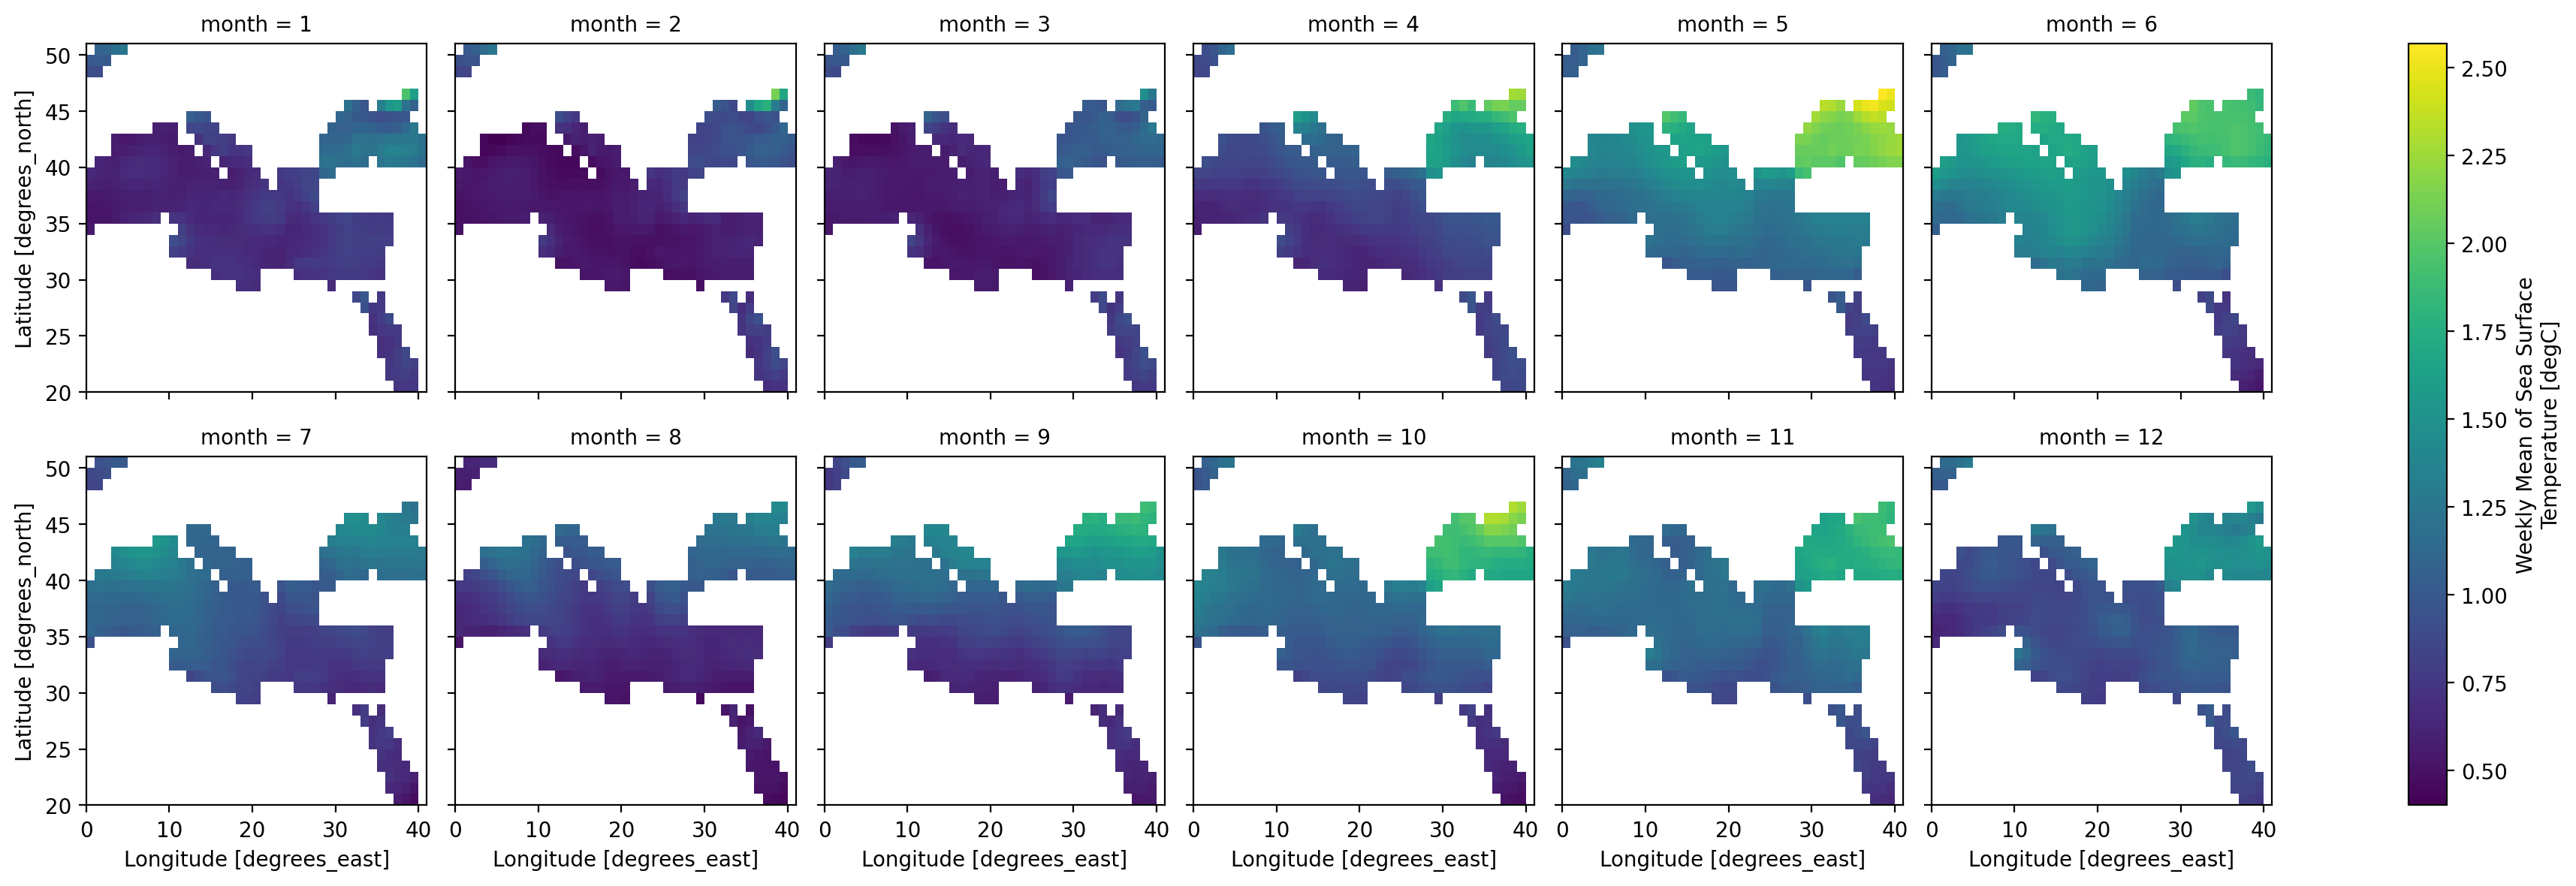

In [11]:
# January: 1 ... December: 12
print("Mean/Std Climatology per month over period 1992 - 2023")

tos_clim.plot(col='month', col_wrap=6, cmap='RdBu_r', vmin=0)

tos_std.plot(col='month', col_wrap=6)

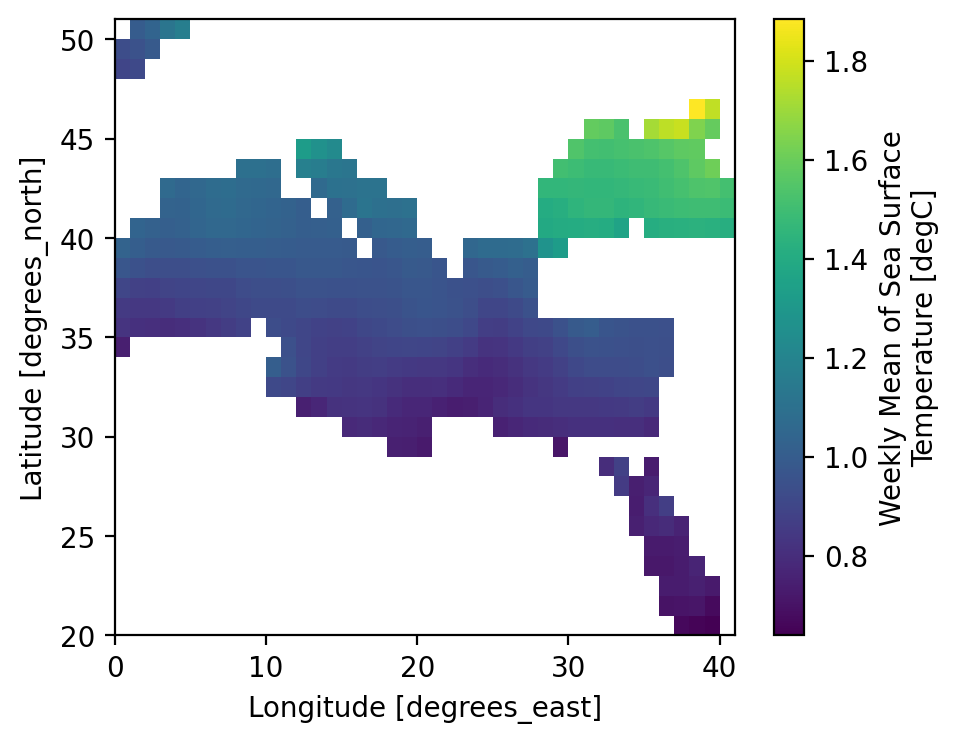

In [12]:
## The average interannual SST variability, averaged across months
# Each month contributes equally, regardless of winter/summer variability

# this would be the initial map displayed, allowing to click on region to display other metrics.
plt.figure(figsize=(5,4))
tos_std.mean(dim='month').plot()
# answer “Where is SST variable across years, on average over the seasonal cycle?”

2. Anomalies

In [13]:
# anomalies: (seasonal cycle removed)
tos_anom = sst_gb - tos_clim
print(tos_anom.dims, tos_anom.shape)
tos_anom.shape

('time', 'lat', 'lon') (1727, 31, 41)


(1727, 31, 41)

In [14]:
# User click on one point on the map which selects coordinates. (to build)
sel_lat_idx, sel_lon_idx = 45, 35

(1727,)


Text(0.5, 0, 'Time (months)')

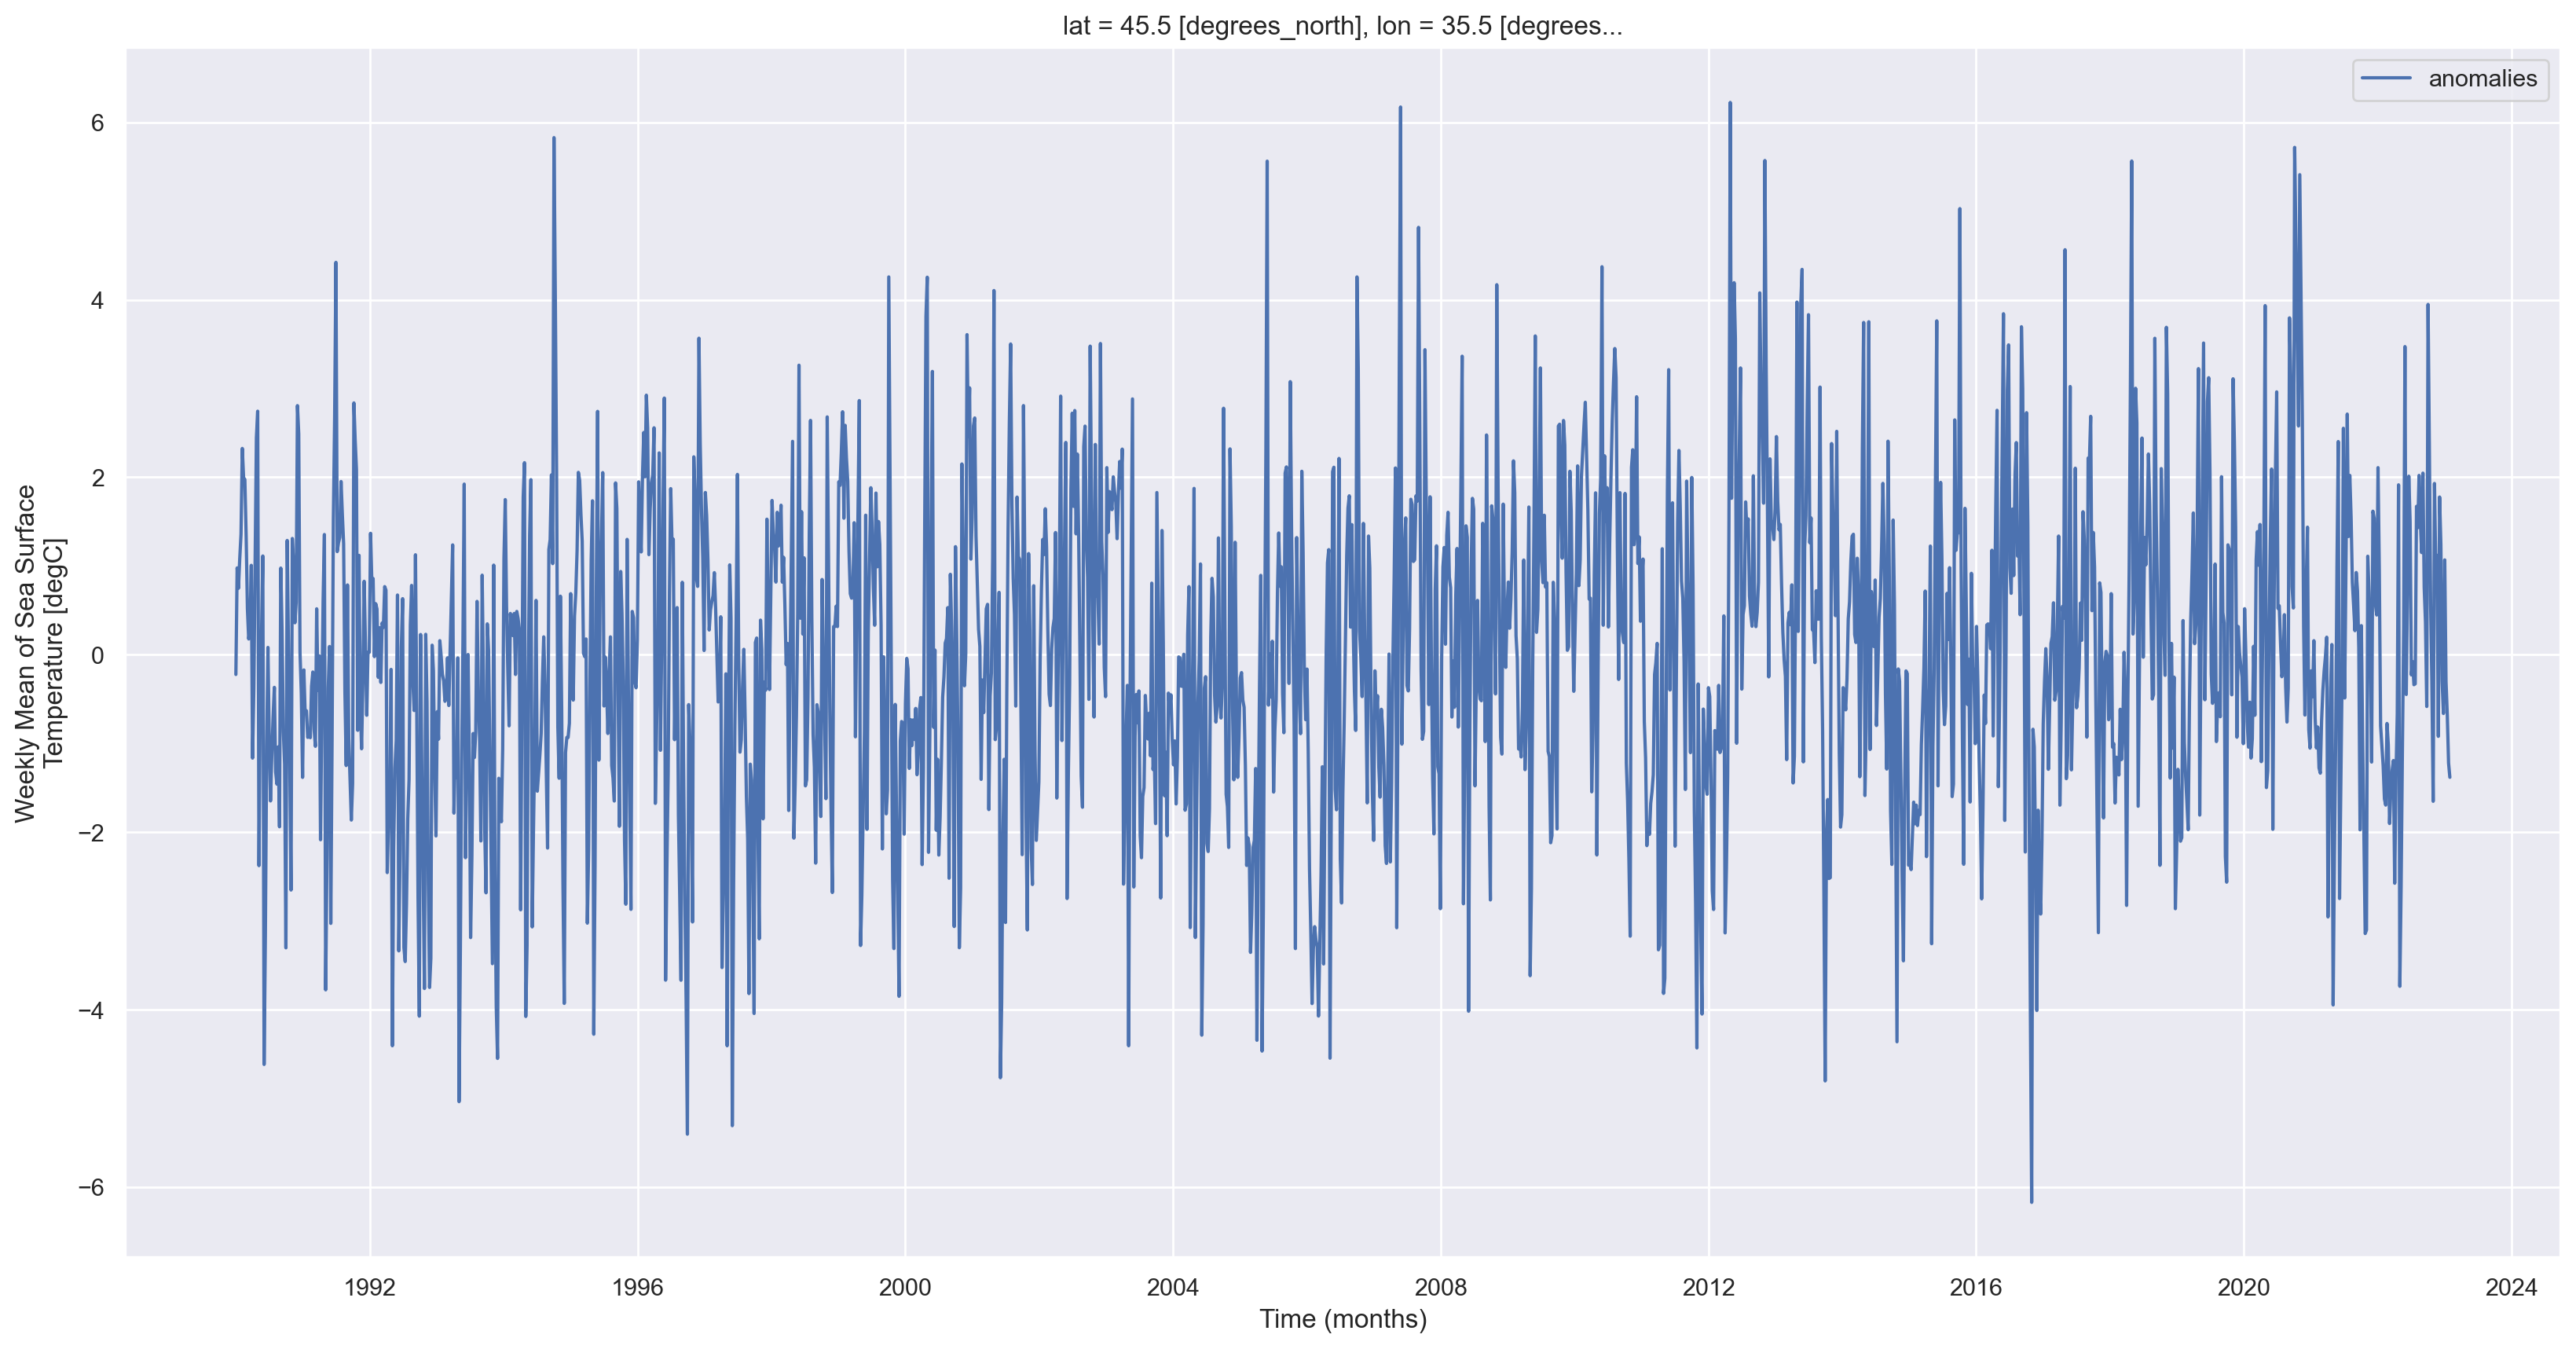

In [34]:
# step 2.1: Trend over years
plt.figure(figsize=(20,10))
tos_anom_selected = tos_anom.sel(lon=sel_lon_idx, lat=sel_lat_idx, method="nearest")
tos_anom_selected.plot()
print(tos_anom_selected.shape)

# weighted mean anomaly in region
# weighted_anom = tos_anom.mean(dim=["lat", "lon"])
# print(weighted_anom.shape)
# weighted_anom.plot()

plt.legend(["anomalies"])
plt.xlabel("Time (months)")

In [39]:
df['continuous_time'] = tos_anom_selected.time

In [16]:
# Linear regression (and others) don’t care about “dates”, need to change to meaningful scale
# standard is to convert time to decimal years

In [36]:
tos_anom_selected.time.values.shape

(1727,)

In [40]:
df['continuous_time'] = tos_anom_selected.time.dt.year + (tos_anom_selected.time.dt.dayofyear - 1) / 365.25

(array(['1989-12-31T00:00:00.000000000', '1990-01-07T00:00:00.000000000',
        '1990-01-14T00:00:00.000000000', ...,
        '2023-01-15T00:00:00.000000000', '2023-01-22T00:00:00.000000000',
        '2023-01-29T00:00:00.000000000'],
       shape=(1727,), dtype='datetime64[ns]'),
 array([1989.99657769, 1990.0164271 , 1990.03559206, ..., 2023.03832991,
        2023.05749487, 2023.07665982], shape=(1727,)),
 array([-0.22238159,  0.9785404 ,  0.7485404 , ..., -0.6814594 ,
        -1.2214594 , -1.3814592 ], shape=(1727,), dtype=float32))

In [70]:
anom_resampled = tos_anom_selected.resample(time='SME').mean('time')
sme_step =24 # 2* 12

In [65]:
year_min, year_max = int(tos_anom_selected.time.dt.year.min()), int(tos_anom_selected.time.dt.year.max())

In [64]:
y_month = np.arange(year_min+1, year_max+1/sme_step, step=1/sme_step)
print(y_month.shape)

(794,)


In [66]:
rolling_year_num=3
rolling_year_avg = anom_resampled.rolling(time=sme_step*rolling_year_num, center=True).mean()

In [72]:
y_month

array([1990.        , 1990.04166667, 1990.08333333, 1990.125     ,
       1990.16666667, 1990.20833333, 1990.25      , 1990.29166667,
       1990.33333333, 1990.375     , 1990.41666667, 1990.45833333,
       1990.5       , 1990.54166667, 1990.58333333, 1990.625     ,
       1990.66666667, 1990.70833333, 1990.75      , 1990.79166667,
       1990.83333333, 1990.875     , 1990.91666667, 1990.95833333,
       1991.        , 1991.04166667, 1991.08333333, 1991.125     ,
       1991.16666667, 1991.20833333, 1991.25      , 1991.29166667,
       1991.33333333, 1991.375     , 1991.41666667, 1991.45833333,
       1991.5       , 1991.54166667, 1991.58333333, 1991.625     ,
       1991.66666667, 1991.70833333, 1991.75      , 1991.79166667,
       1991.83333333, 1991.875     , 1991.91666667, 1991.95833333,
       1992.        , 1992.04166667, 1992.08333333, 1992.125     ,
       1992.16666667, 1992.20833333, 1992.25      , 1992.29166667,
       1992.33333333, 1992.375     , 1992.41666667, 1992.45833

Text(0.5, 0, 'Time (months)')

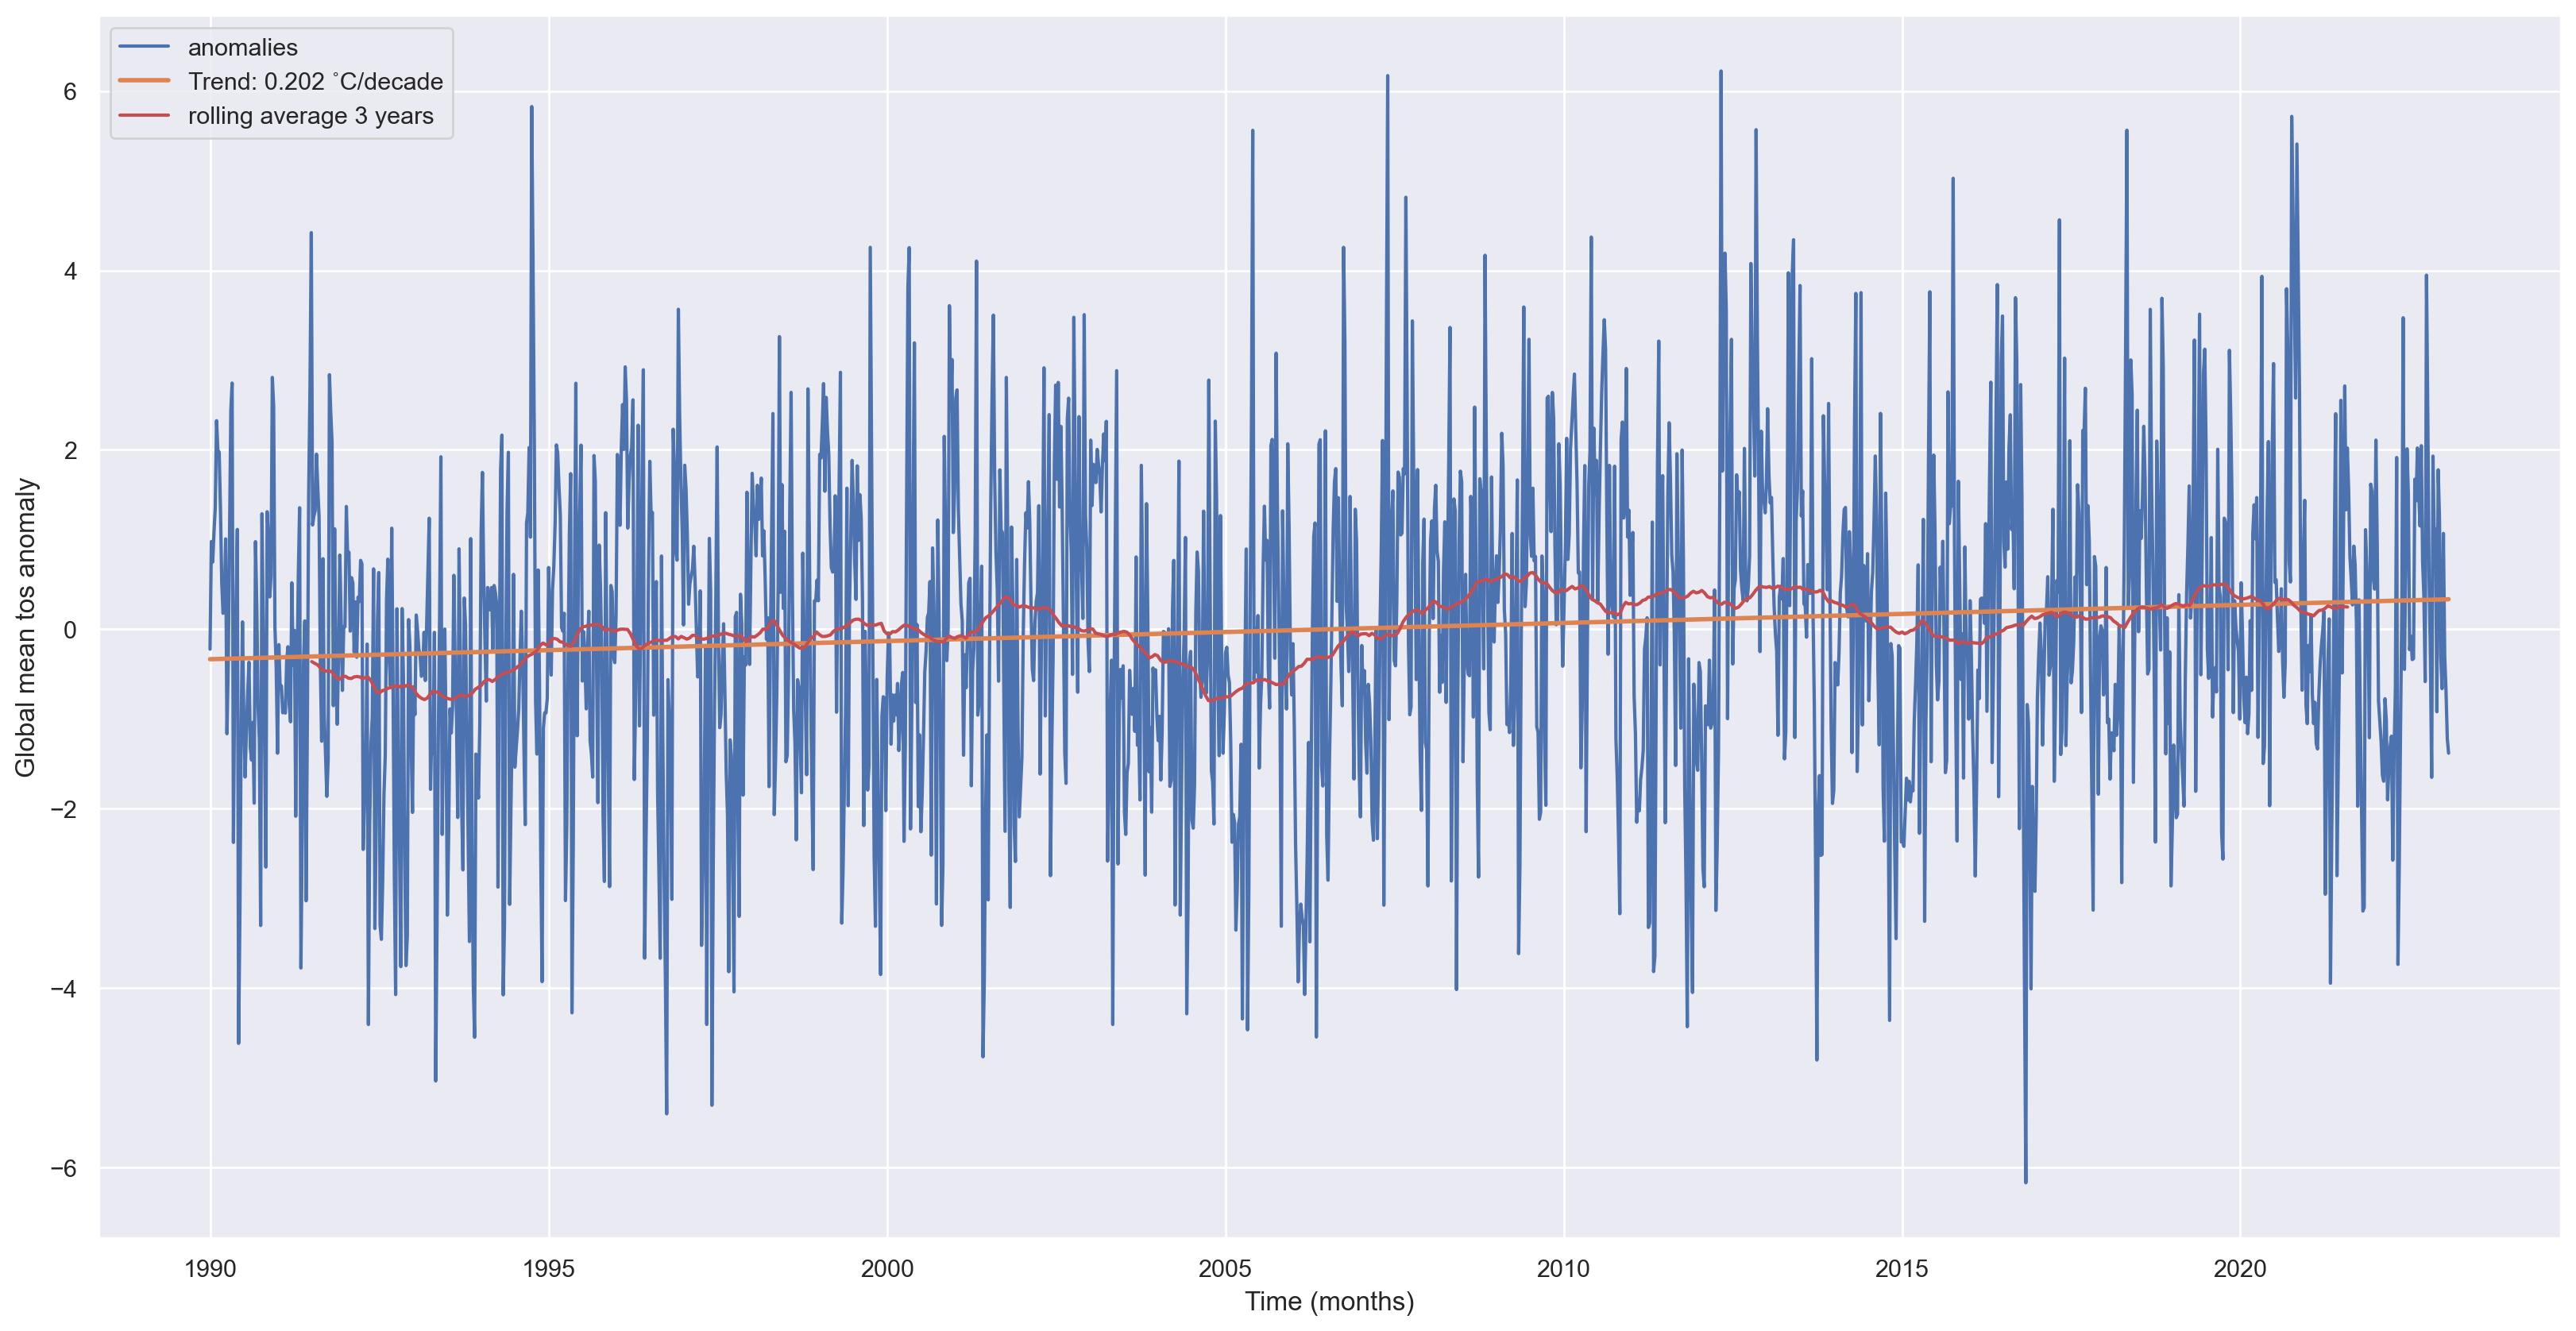

In [67]:
# a. OLS
X = df['continuous_time'].to_numpy().reshape(-1,1)
y = df['anomalies'].to_numpy().reshape(-1,1)


reg = LinearRegression().fit(X, y)
trend = np.round(reg.coef_[0,0] *10,3) # celcius / decade # ##for " ˚ " -> option + K
plt.figure(figsize=(20,10))
plt.plot(X,y)
plt.plot(X, reg.predict(X), linewidth=2)
plt.plot(y_month, rolling_year_avg, 'r')

plt.legend(["anomalies", f"Trend: {trend} ˚C/decade", f"rolling average {rolling_year_num} years"])
plt.ylabel("Global mean tos anomaly")
plt.xlabel("Time (months)")

Extreme Anomalies
-> very warm event that cannot be called heatwaves (heatwaves are > 5days of high temperature but data is weekly/biweekly)

In [23]:
q90 = np.quantile(tos_anom_selected, q=0.90)
q95 = np.quantile(tos_anom_selected, q=0.95)

q10 = np.quantile(tos_anom_selected, q=0.10)
q05 = np.quantile(tos_anom_selected, q=0.05)


Text(0.5, 0, 'Time (months)')

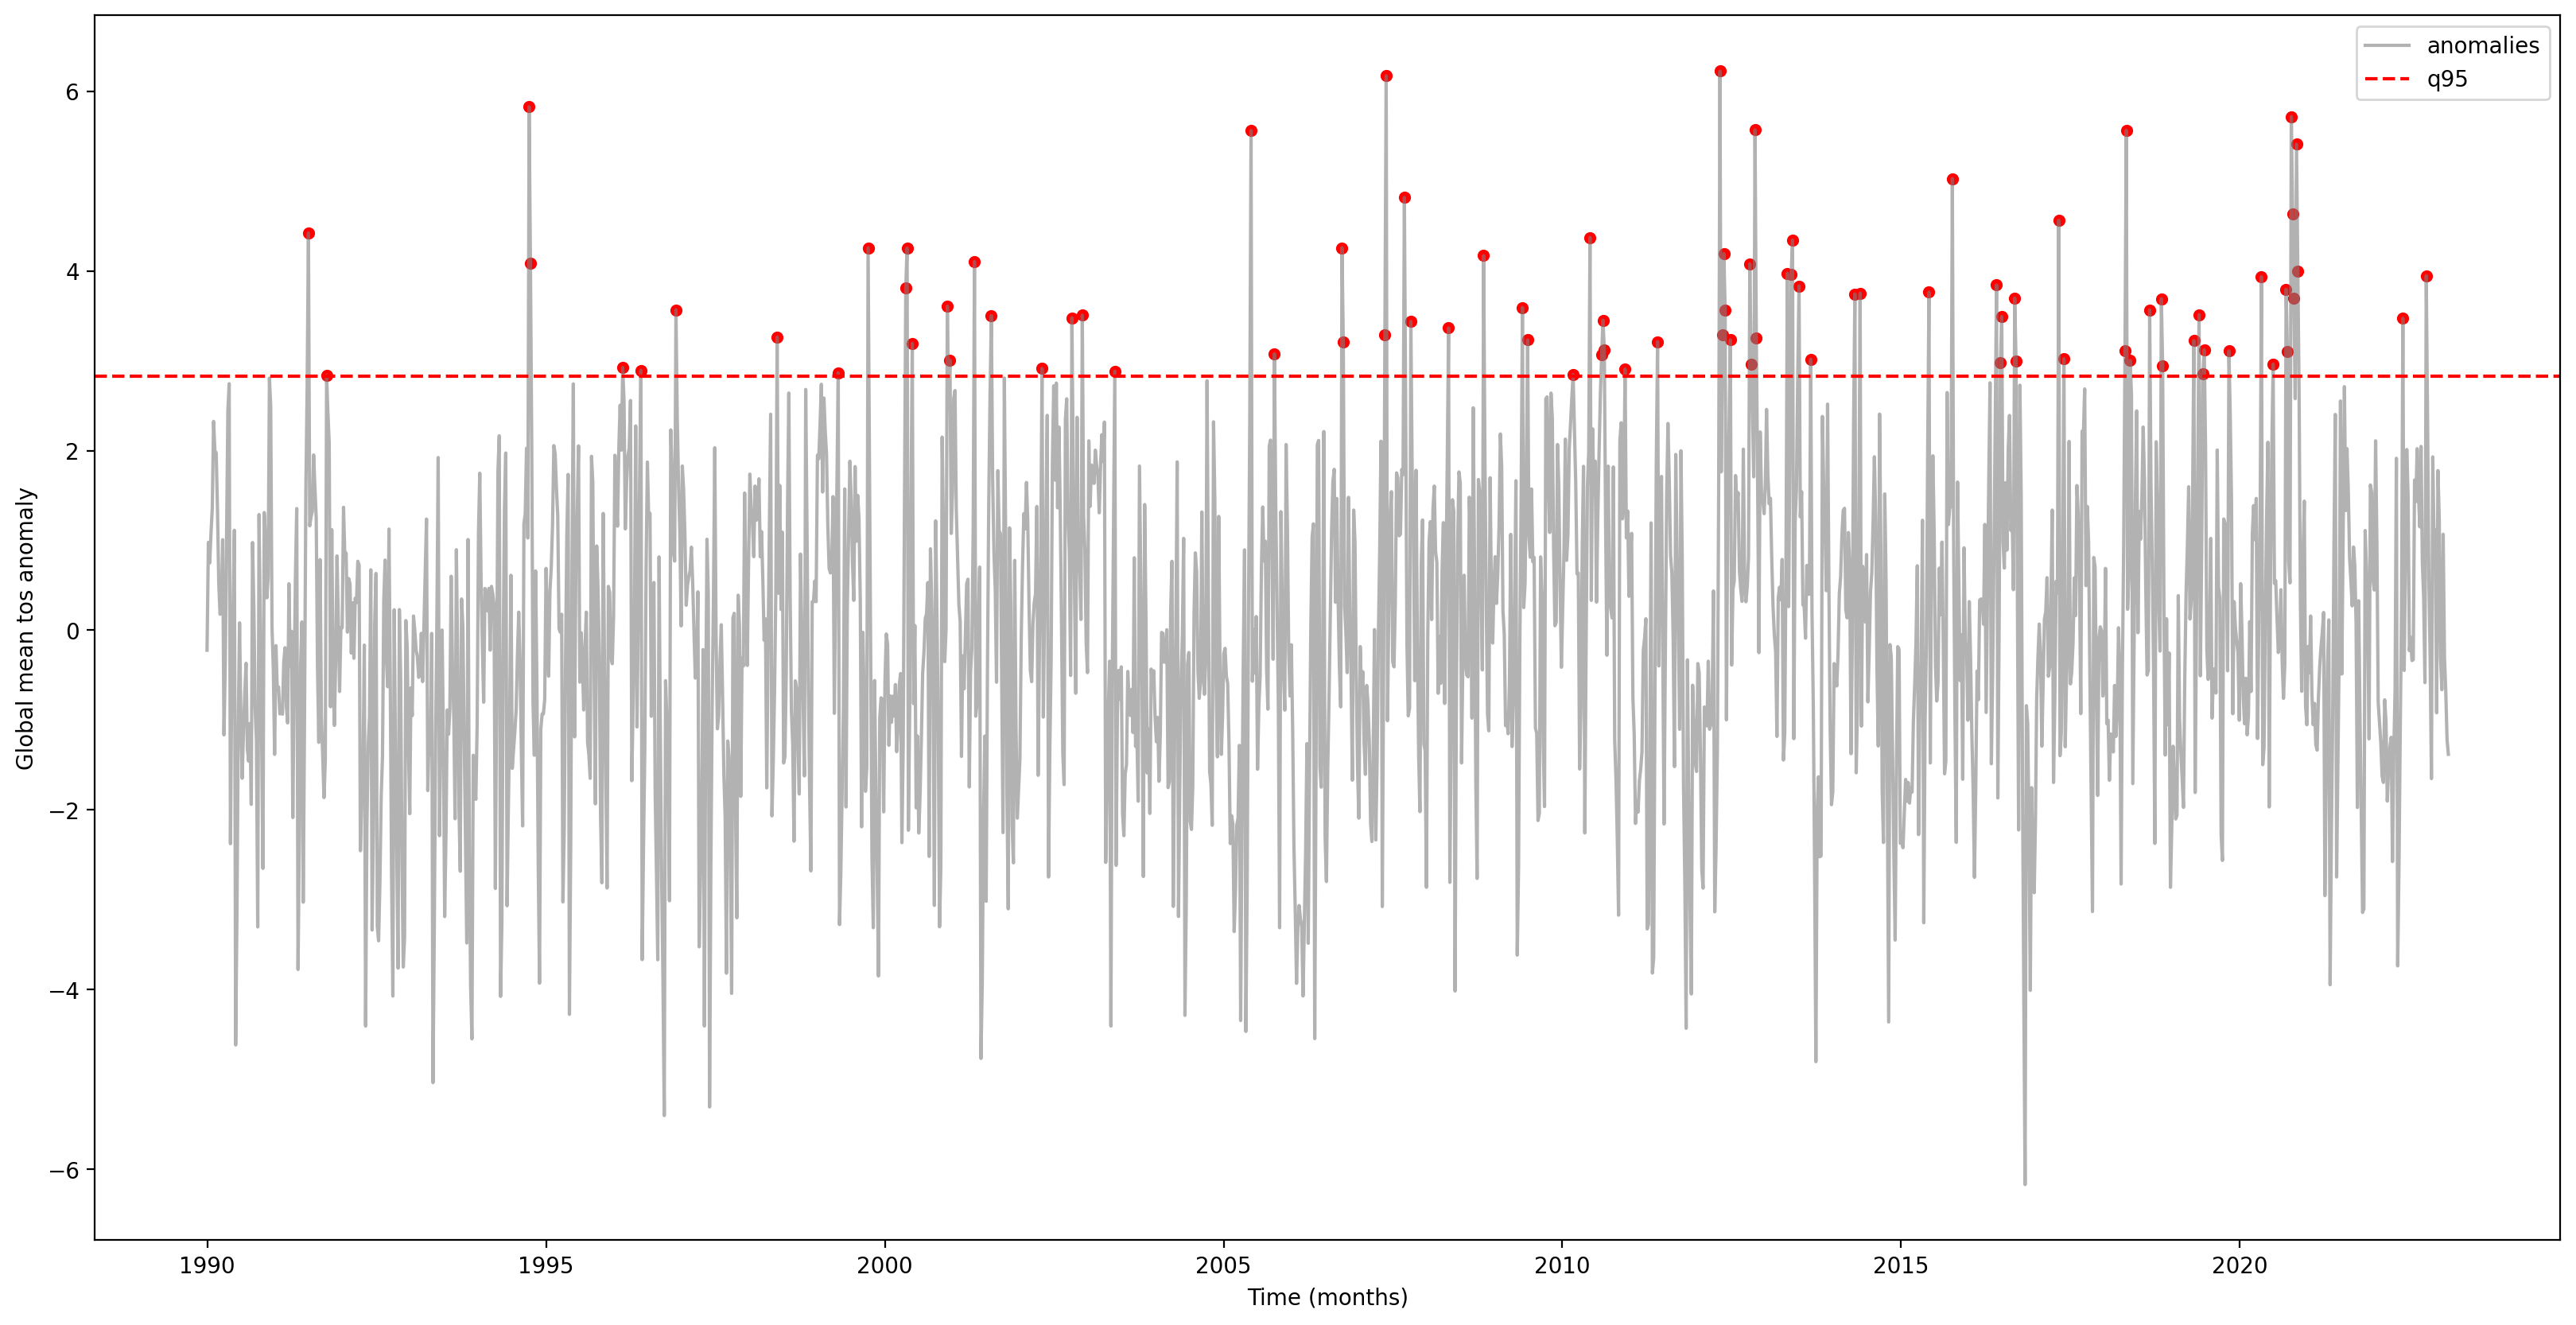

In [24]:
plt.figure(figsize=(20,10))
plt.plot(X,y, color='gray', alpha=0.6)

plt.axhline(q95, color='red', linestyle='--', label='90th percentile')
# plt.axhline(q05, color='blue', linestyle='--', label='5th percentile')


plt.scatter(X[y > q95],
            y[y > q95],
            color='red', s=20, label='Extreme')

plt.legend(["anomalies","q95"])
plt.ylabel("Global mean tos anomaly")
plt.xlabel("Time (months)")

In [38]:
df = pd.DataFrame(data={'anomalies': y[:,0], 
                        'time': tos_anom_selected.time.dt.year},)

# df = df.loc[df['time']!=2023] # only one month recorded

In [27]:
sns.set_theme(style="darkgrid")

# df['q90'] = (df['anomalies'] > q90).astype(int)*df['anomalies']
df['q95'] = (df['anomalies'] > q95).astype(int)

# df['q10'] = (df['anomalies'] < q10).astype(int)*df['anomalies']
# df['q05'] = (df['anomalies'] < q05).astype(int)*df['anomalies']

In [28]:
df_sel = df.loc[df['q95'] == 1]

In [30]:
df_sel['q95'].value_counts()

q95
1    87
Name: count, dtype: int64

In [33]:
df_sel

,anomalies,time,q95
78,4.422274,1991,1
92,2.838017,1991,1
248,5.828016,1994,1
249,4.088017,1994,1
320,2.925188,1996,1
...,...,...,...
1607,3.698015,2020,1
1609,5.410142,2020,1
1610,4.000142,2020,1
1691,3.472925,2022,1


Text(0.5, 1.0, 'Number of Exteme Warm Anomalies per year')

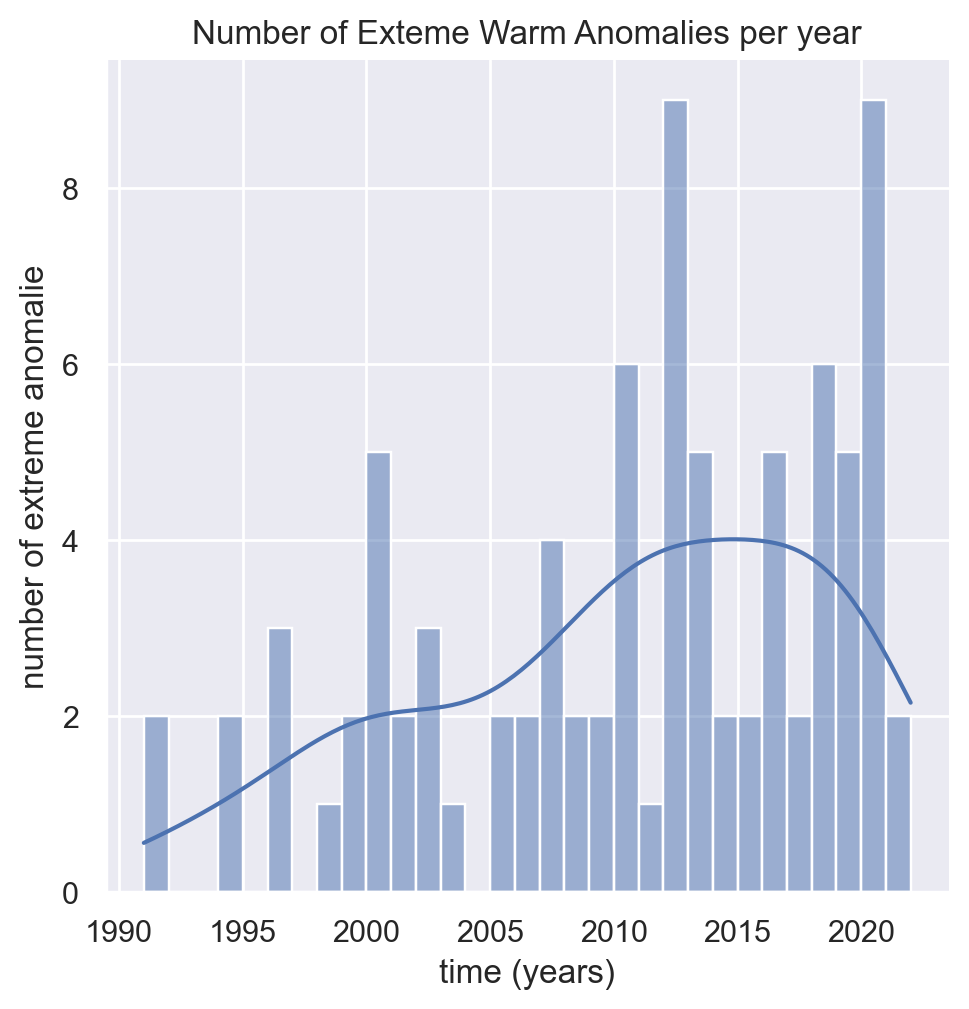

In [32]:
ax=sns.displot(data = df_sel, x = 'time', binwidth=1, kde=True, height=5)
ax.set_xlabels('time (years)')
ax.set_ylabels('number of extreme anomalie')
plt.title('Number of Exteme Warm Anomalies per year')